# Classics

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# import generative as gen
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
# import utils as ut
import seaborn as sns
import h5py
from vizman import viz
import networkx as nx
from netneurotools.networks import threshold_network
import pandas as pd

In [3]:
viz.set_visual_style()
viz_sizes = viz.load_data_from_json("sizes.json")
viz_colors = viz.load_data_from_json("colors.json")
viz_cmaps = viz.give_colormaps()
sns_kwargs = {"cmap": viz_cmaps["bw_lr"],
              "xticklabels":False,
              "yticklabels":False,
              "rasterized":True}

In [4]:
colors = [viz_colors["colds"]["LAKE_BLUE"], # routing
          viz_colors["neutrals"]["OLIVE_GRAY"], # diffusion
          viz_colors["purples"]["PURPLER"], # propagation
          viz_colors["warms"]["LECKER_RED"], # empirical
          "#a2313a", # long-range rewired
          "#C6C7C4", # randomized
          "#A2999E", # latticized
          "#353B3C"] # erdos-renyi

# Loading connectivity matrices and so on

In [5]:
parcellation = "Schaefer" # "Schaefer" or "DK68"

In [6]:
# data = h5py.File(
#     f"datasets/human/{parcellation}/DTI_fibers_VolNorm_HCP.mat",
# )

In [7]:
if parcellation == "Schaefer":
    N_regions = 100
elif parcellation == "DK68":
    N_regions = 68
N_subjects = 100

In [8]:
# connectivities = np.zeros((N_regions,N_regions,N_subjects))
# for subject in range(N_subjects):
#     ref = data["DTI_fibers_VolNorm_HCP"][0][subject]
#     connectivities[...,subject]=data[ref][()]

In [9]:
# empirical_densities = []
# for subject in range(N_subjects):
#     empirical_densities.append(ut.check_density(connectivities[...,subject].astype(bool)))

In [10]:
# thresholded_connectivities = np.zeros_like(connectivities)
# for subject in range(N_subjects):
#     thresholded_connectivities[...,subject] = threshold_network(connectivities[...,subject], 20)

In [12]:
# diffusion_matrices = np.load(f"simulations/{parcellation}/diffusion/diffusion_lastmats.npy")
# routing_matrices = np.load(f"simulations/{parcellation}/routing/routing_lastmats.npy")
# propagation_matrices = np.load(f"simulations/{parcellation}/propagation/propagation_lastmats.npy")

In [13]:
# latticized_matrices = np.load(f"simulations/{parcellation}/latticized.npy")
# randomized_matrices = np.load(f"simulations/{parcellation}/randomized.npy")
# erdos_renyi_matrices = np.load(f"simulations/{parcellation}/erdos_renyi.npy")

In [14]:
# all_measures = pd.read_csv(f"results/{parcellation}/all_measures.csv")
# all_measures = all_measures[all_measures['model'] != 'Homophily']

In [15]:
# all_measures['model']

In [16]:
measure = "memory capacity"

In [17]:
# plt.figure(figsize=(viz.cm_to_inch((6,5))), dpi=150)
# sns.stripplot(data=all_measures, 
#             y="model",
#             x=measure,
#             hue="model",
#             size=3,
#             jitter=0.4,
#             palette=colors)

# empirical_values = all_measures[all_measures['model'] == 'Empirical'][measure]
# plt.axvspan(empirical_values.min(),empirical_values.max(), color=viz_colors["warms"]["LECKER_RED"], alpha=0.1)

# plt.xlabel(measure.capitalize())
# plt.ylabel("")
# sns.despine()

In [18]:
# all_measures[all_measures['model'] == 'Empirical']['memory capacity']

In [19]:
# structural_robustness = np.zeros((2,N_regions,N_subjects))
# for subject in range(N_subjects):
#     lesioned_propagation = propagation_matrices[...,subject].copy()
#     lesioned_empirical = thresholded_connectivities[...,subject].copy()    

#     for index, node_index in enumerate(np.argsort(propagation_matrices[...,subject].sum(0))[::-1]):
#         lesioned_propagation[node_index,:] = 0
#         lesioned_propagation[:,node_index] = 0
#         lesioned_G = nx.from_numpy_array(lesioned_propagation)
#         structural_robustness[0,index,subject] = nx.global_efficiency(lesioned_G)
#     for index, node_index in enumerate(np.argsort(thresholded_connectivities[...,subject].sum(0))[::-1]):
#         lesioned_empirical[node_index,:] = 0
#         lesioned_empirical[:,node_index] = 0
#         lesioned_G = nx.from_numpy_array(lesioned_empirical)
#         structural_robustness[1,index,subject] = nx.global_efficiency(lesioned_G)

# Memory capacity related 

In [20]:
from functools import partial
from sklearn.model_selection import train_test_split
from echoes import ESNRegressor

from src.analysis.utils_kayson_damicelli import forgetting, make_X_y
import src.analysis.utils_kayson_damicelli as ut

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [21]:
lags=np.arange(1, 41)
X, y = ut.make_X_y(
    make_X=partial(np.random.uniform, low=0, high=1, size=3000),
    lags=lags,
    cut=0
)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2400, 1), (600, 1), (2400, 40), (600, 40))

In [22]:
MEASURE = True # False

In [23]:
diffusion_matrices.shape
N_subjects = 1

In [24]:
diffusion_matrices.shape

(100, 100, 1)

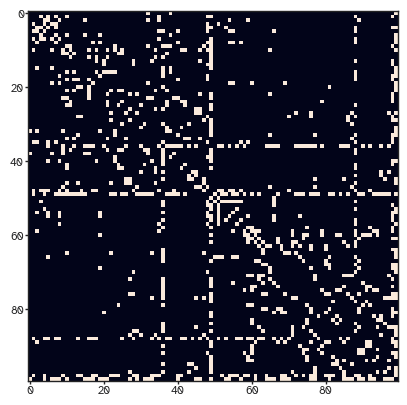

In [25]:
plt.imshow(diffusion_matrices[...,0])


In [26]:
# if MEASURE:
#     n_lags = 40

#     # Assume propagation_matrices and thresholded_connectivities are available, shape: (N_regions, N_regions, N_subjects)
#     N_regions, _, _ = diffusion_matrices.shape # propagation_matrices.shape
#     N_trials = 200

#     propagation_performances = np.zeros((N_trials, N_subjects))
#     empirical_performances = np.zeros((N_trials, N_subjects, len(N_tops)))

#     for subject in tqdm(range(N_subjects),total=N_subjects):
#         for trial in range(N_trials):          
#             # Propagation
#             esn = ESNRegressor(W=np.array(diffusion_matrices[...,subject]), # , dtype=np.float32),
#                                 input_scaling=1e-5,
#                                 n_transient=100,
#                                 # W_in=np.array(propagation_mask[subject][:,np.newaxis], dtype=np.float32),
#                                 random_state=subject+trial
#                                 )
#             y_pred = esn.fit(X_train, y_train).predict(X_test)
#             result = ut.forgetting(y_test[100:], y_pred[100:])
#             propagation_performances[trial,subject]=result[1]
            
#             plt.plot(result[0])
#             print("MC:", result[1])


#     for subject in tqdm(range(N_subjects),total=N_subjects):
#         for trial in range(N_trials):          
#             # Propagation
#             esn = ESNRegressor(W=np.array(diffusion_matrices[...,subject]), # , dtype=np.float32),
#                                 input_scaling=1e-5,
#                                 n_transient=100,
#                                 # W_in=np.array(propagation_mask[subject][:,np.newaxis], dtype=np.float32),
#                                 random_state=subject+trial
#                                 )
#             y_pred = esn.fit(X_train, y_train**2).predict(X_test)
#             result = ut.forgetting(y_test**2[100:], y_pred[100:])
#             propagation_performances[trial,subject] = result[1]
#             plt.plot(result[0])
#             print("MC:", result[1])
#         # break
#                 # # Empirical
#                 # esn = ESNRegressor(W=thresholded_connectivities[...,subject],
#                 #                     input_scaling=1e-5,
#                 #                     n_transient=100,
#                 #                     W_in=empirical_mask[subject][:,np.newaxis],
#                 #                     random_state=subject+trial)
#                 # y_pred = esn.fit(X_train, y_train).predict(X_test)
#                 # empirical_performances[trial,subject,idx]=ut.forgetting(y_test[100:], y_pred[100:])[1]

# #     np.save(f"results/{parcellation}/propagation_MC_lesions.npy", propagation_performances)
# #     np.save(f"results/{parcellation}/empirical_MC_lesions.npy", empirical_performances)
# #     print(f"results/{parcellation}/propagation_MC_lesions.npy") 
# # # else:
# # propagation_performances = np.load(f"results/{parcellation}/propagation_MC_lesions.npy")
# # empirical_performances = np.load(f"results/{parcellation}/empirical_MC_lesions.npy")

# # plt.plot(ut.forgetting(y_test[100:], y_pred[100:])[0])


In [27]:
# Alleine das ändern der input_scaling auf 10e-3 hat die MC stark verbessert... Das als neue property, die dann weniger noisy ist? 

100%|██████████| 1/1 [00:02<00:00,  2.12s/it]

MC: 7.074969968090087


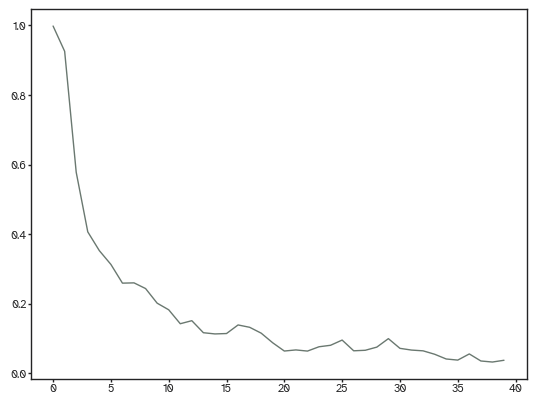

In [28]:
if MEASURE:

    # Assume propagation_matrices and thresholded_connectivities are available, shape: (N_regions, N_regions, N_subjects)
    N_regions, _, _ = diffusion_matrices.shape # propagation_matrices.shape
    N_tops = [1, 5, 10, 15, 20]
    N_trials = 100

    propagation_performances = np.zeros((N_trials, N_subjects, len(N_tops)))
    empirical_performances = np.zeros((N_trials, N_subjects, len(N_tops)))

    for idx, N_top in enumerate(N_tops):
        propagation_mask = np.ones((N_subjects, N_regions))
        # empirical_mask = np.ones((N_subjects, N_regions))

        for subject in range(N_subjects):
            # Propagation: zero out top N_top highest-degree regions
            A_prop = diffusion_matrices[..., subject]
            degree_prop = A_prop.sum(axis=0)
            top_idx_prop = np.argsort(degree_prop)[::-1][:max(0, min(N_top, N_regions))]
            mask_prop = np.ones_like(degree_prop)
            if top_idx_prop.size > 0:
                mask_prop[top_idx_prop] = 0
            propagation_mask[subject] = mask_prop

            # # Empirical: zero out top N_top highest-degree regions
            # A_emp = thresholded_connectivities[..., subject]
            # degree_emp = A_emp.sum(axis=0)
            # top_idx_emp = np.argsort(degree_emp)[::-1][:max(0, min(N_top, N_regions))]
            # mask_emp = np.ones_like(degree_emp)
            # if top_idx_emp.size > 0:
            #     mask_emp[top_idx_emp] = 0
            # empirical_mask[subject] = mask_emp
            # break
            
        for subject in tqdm(range(N_subjects),total=N_subjects):
            for trial in range(N_trials):          
                # Propagation
                esn = ESNRegressor(W=np.array(diffusion_matrices[...,subject]), # , dtype=np.float32),
                                    input_scaling=0.1, # 1, # 1e-3, # 0.5,
                                    leak_rate=0.3, 
                                    bias=0, 
                                    # bias=0.5,
                                    n_transient=100,
                                    # W_in=np.array(propagation_mask[subject][:,np.newaxis], dtype=np.float32),
                                    random_state=subject+trial
                                    )
                y_pred = esn.fit(X_train, y_train).predict(X_test)
                
                            
                # # 3. Calculate the MC score
                # mc_score = 0
                # r2_scores = []
                # for i in range(n_lags):
                #     # Discard initial transient phase from test data for stable correlation
                #     corr, _ = pearsonr(y_test[h_params["n_transient"]:, i], y_pred[h_params["n_transient"]:, i]) # Discard initial transient. (statistic, p_value)
                #     r2_scores.append(corr**2)
                #     mc_score += corr**2
                
                
                propagation_performances[trial,subject,idx]=ut.forgetting(y_test[100:], y_pred[100:])[1]
                
                
            # break
                    # # Empirical
                    # esn = ESNRegressor(W=thresholded_connectivities[...,subject],
                    #                     input_scaling=1e-5,
                    #                     n_transient=100,
                    #                     W_in=empirical_mask[subject][:,np.newaxis],
                    #                     random_state=subject+trial)
                    # y_pred = esn.fit(X_train, y_train).predict(X_test)
                    # empirical_performances[trial,subject,idx]=ut.forgetting(y_test[100:], y_pred[100:])[1]

#     np.save(f"results/{parcellation}/propagation_MC_lesions.npy", propagation_performances)
#     np.save(f"results/{parcellation}/empirical_MC_lesions.npy", empirical_performances)
#     print(f"results/{parcellation}/propagation_MC_lesions.npy") 
# # else:
    # propagation_performances = np.load(f"results/{parcellation}/propagation_MC_lesions.npy")
    # empirical_performances = np.load(f"results/{parcellation}/empirical_MC_lesions.npy")
    
plt.plot(ut.forgetting(y_test[100:], y_pred[100:])[0])
print("MC:", ut.forgetting(y_test[100:], y_pred[100:])[1])

In [29]:
from scipy.stats import pearsonr

In [30]:
np.sum(ut.forgetting(y_test[100:], y_pred[100:])[0])

np.float64(7.074969968090087)

In [31]:
ut.forgetting(y_test[100:], y_pred[100:])[1]

np.float64(7.074969968090087)

In [32]:
y_pred, y_test

r2_lags = []
for i in range(40):
    corr, _ = pearsonr(y_test[100:, i], y_pred[100:, i]) # Discard initial transient. (statistic, p_value)
    r2_lags.append(corr**2) 
    # print(f"Lag {i+1}: R^2 = {corr**2:.4f}")

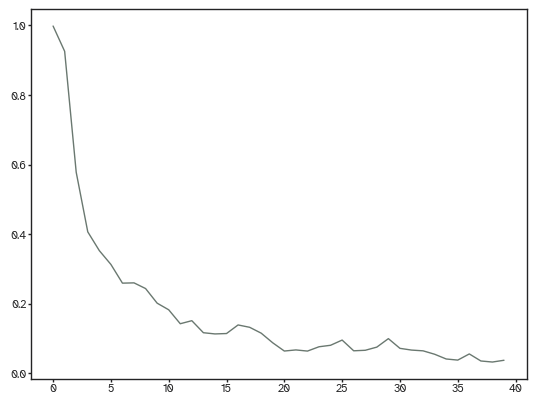

In [33]:
plt.plot(r2_lags)

In [34]:
# # 3. Calculate the MC score
# mc_score = 0
# r2_scores = []
# for i in range(40):
#     # Discard initial transient phase from test data for stable correlation
#     corr, _ = pearsonr(y_test[h_params["n_transient"]:, i], y_pred[h_params["n_transient"]:, i]) # Discard initial transient. (statistic, p_value)
#     r2_scores.append(corr**2)
#     mc_score += corr**2


In [35]:
propagation_performances.shape

(100, 1, 5)

6.8818610891206555


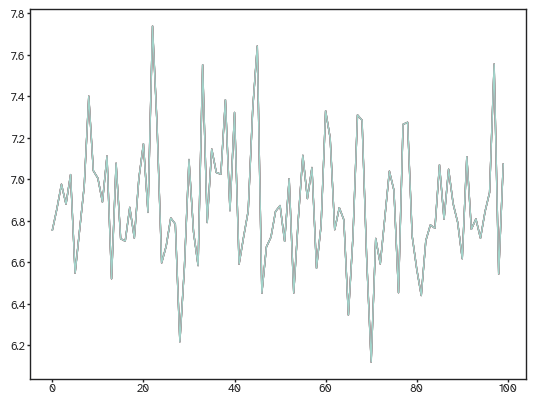

In [36]:
plt.plot(propagation_performances[:, 0, :]) 
print(propagation_performances[:, 0, :].mean())

In [37]:
trial_avg_propagation = np.mean(propagation_performances, axis=0)
trial_avg_propagation
# trial_avg_empirical = np.mean(empirical_performances, axis=0)

array([[6.88186109, 6.88186109, 6.88186109, 6.88186109, 6.88186109]])

In [38]:
# diff_empirical = all_measures[all_measures['model'] == 'Empirical'][measure].values[:, None] - trial_avg_empirical
# diff_propagation = all_measures[all_measures['model'] == 'Propagation'][measure].values[:, None] - trial_avg_propagation

In [39]:
# # build long-form dataframe with one row per (subject, N_lesioned, network)
# n_subjects, n_tops = diff_empirical.shape
# emp_flat = diff_empirical.ravel()   # shape n_subjects * n_tops
# prop_flat = diff_propagation.ravel()

# n_lesioned_per_subject = np.tile(N_tops, n_subjects)  # length n_subjects * n_tops

# df_melt = pd.DataFrame({
#     'Network': np.concatenate([np.repeat('Empirical', emp_flat.size),
#                                np.repeat('Propagation', prop_flat.size)]),
#     'Memory Capacity Difference': np.concatenate([emp_flat, prop_flat]),
#     'N lesioned': np.concatenate([n_lesioned_per_subject, n_lesioned_per_subject])
# })

100%|██████████| 1/1 [00:02<00:00,  2.01s/it]

MC: 19.704256208545694


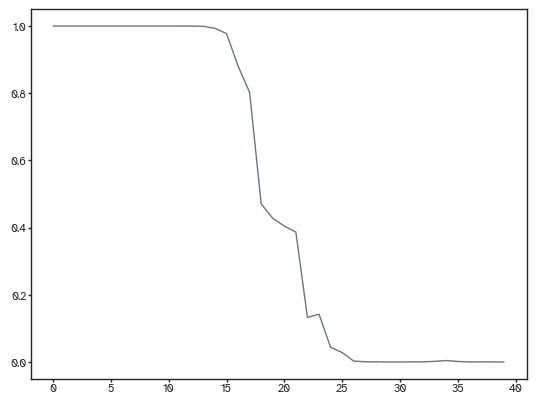

100%|██████████| 1/1 [00:01<00:00,  1.94s/it]

MC: 14.945252661273924


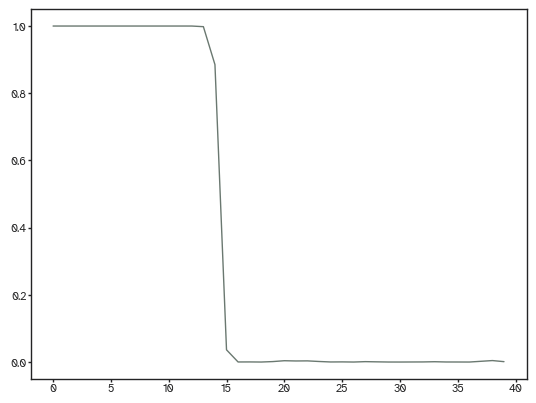

In [ ]:

# def plot_forgetting_curve(A):  # , y_test, y_pred):

#     N_regions, _, _ = A.shape
#     N_trials = 100

#     for subject in tqdm(range(N_subjects),total=N_subjects):
#         for trial in range(N_trials):          
#             # Propagation
#             esn = ESNRegressor(W=np.array(A[...,subject]), # , dtype=np.float32),
#                                 input_scaling=1e-5, # 1, # 1e-3, # 0.5,
#                                 # leak_rate=0.3, 
#                                 bias=0, 
#                                 # bias=0.5,
#                                 n_transient=100,
#                                 # W_in=np.array(propagation_mask[subject][:,np.newaxis], dtype=np.float32),
#                                 random_state=subject+trial
#                                 )
#             y_pred = esn.fit(X_train, y_train).predict(X_test)
            
#             result = ut.forgetting(y_test[100:], y_pred[100:])
        
#     plt.plot(result[0])
#     print("MC:", result[1])
        
#     plt.show()

# plot_forgetting_curve(diffusion_matrices_10)

# plot_forgetting_curve(diffusion_matrices_20)


In [81]:
diffusion_matrices_10 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation_10_percent.npy")
diffusion_matrices_10 = diffusion_matrices_10.T
diffusion_matrices_20 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation_20_percent_gen_by_kayson.npy")
diffusion_matrices_20 = diffusion_matrices_20[:,:,:1]
developing_matrices = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_developing/01_connectomes/00_individual_connectomes_bin.npy")
developing_matrices = developing_matrices.T[:,:,:1]

diffusion_matrices_10.shape, diffusion_matrices_20.shape, developing_matrices.shape

((100, 100, 1), (100, 100, 1), (100, 100, 1))

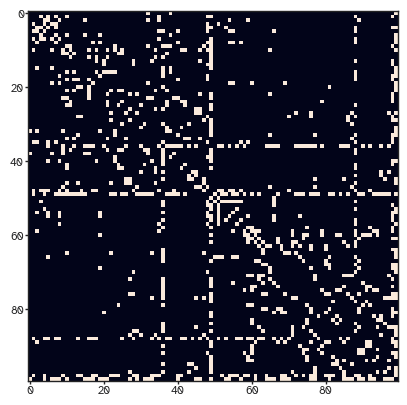

In [ ]:
# plt.imshow(diffusion_matrices_10[...,0])   
# plt.imshow(diffusion_matrices_20[...,0])   
# plt.imshow(developing_matrices[...,0])    

100%|██████████| 1/1 [00:04<00:00,  4.20s/it]

Lin MC: 20.73303170452875
Non-Lin MC: 19.281196470637536


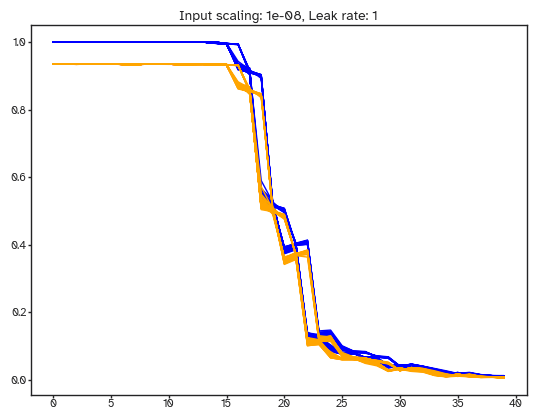

100%|██████████| 1/1 [00:04<00:00,  4.26s/it]

Lin MC: 18.474600853956968
Non-Lin MC: 17.108182255755395


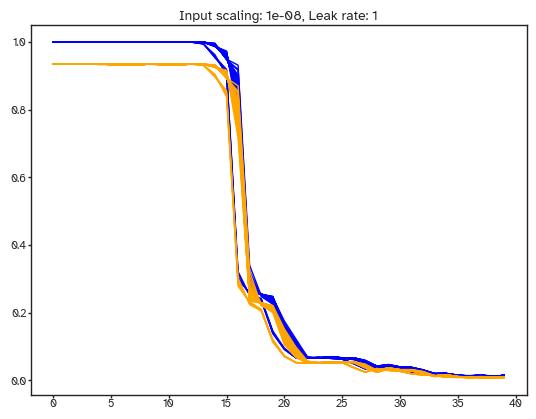

100%|██████████| 1/1 [00:04<00:00,  4.35s/it]

Lin MC: 11.013711072015605
Non-Lin MC: 10.625745139778422


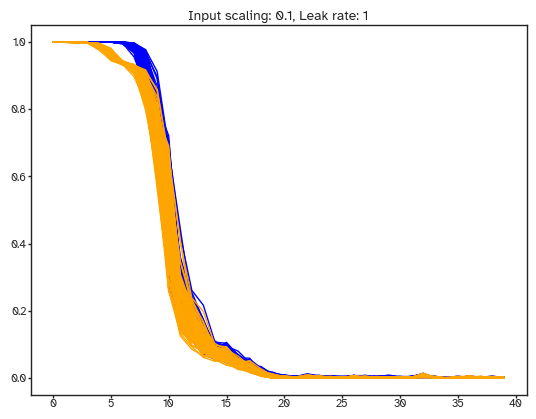

100%|██████████| 1/1 [00:04<00:00,  4.33s/it]

Lin MC: 10.119650204010078
Non-Lin MC: 9.735926452755042


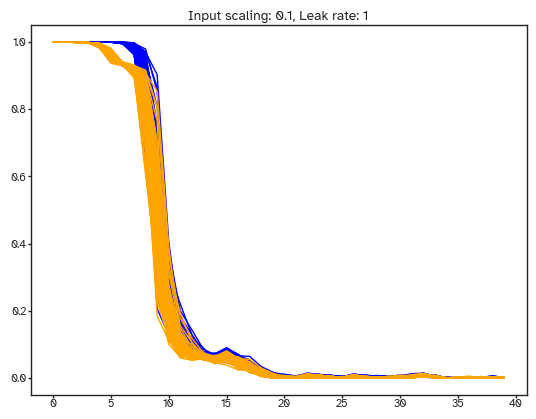

100%|██████████| 1/1 [00:04<00:00,  4.31s/it]

Lin MC: 7.709319902081527
Non-Lin MC: 7.331036890874335


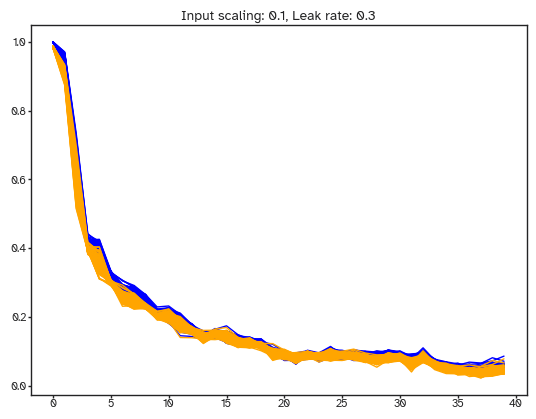

100%|██████████| 1/1 [00:04<00:00,  4.36s/it]

Lin MC: 7.253156454523077
Non-Lin MC: 6.895552330203506


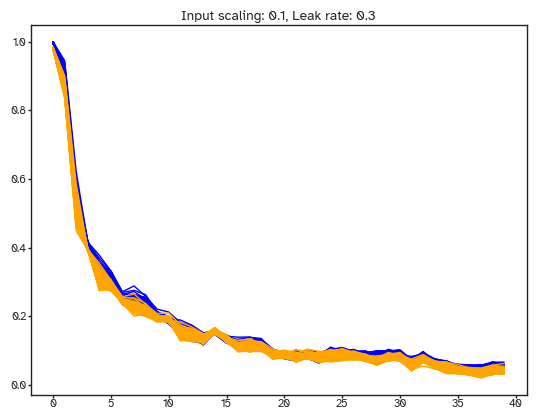

100%|██████████| 1/1 [00:04<00:00,  4.22s/it]

Lin MC: 20.279997879301273
Non-Lin MC: 19.169841547334578


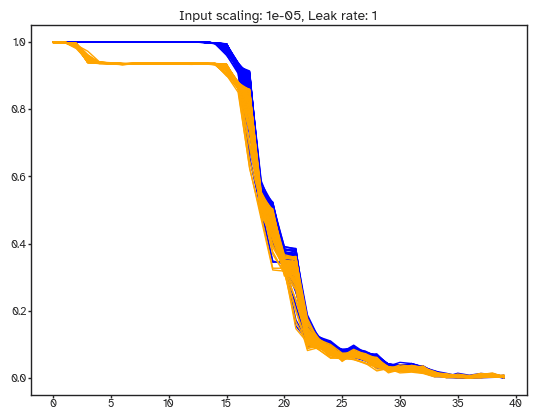

100%|██████████| 1/1 [00:04<00:00,  4.30s/it]

Lin MC: 17.754968021660208
Non-Lin MC: 16.739109563751025


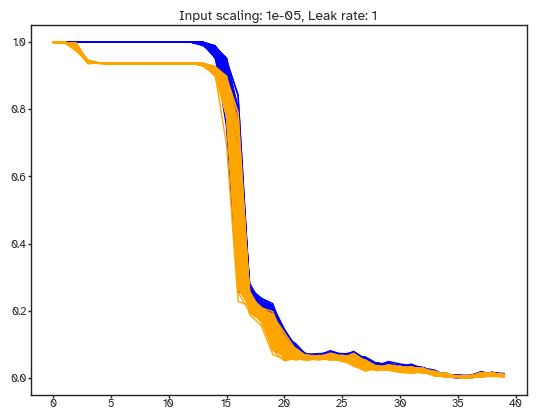

In [ ]:
def plot_forgetting_curve(A, input_scaling, leak_rate):  # , y_test, y_pred):

    N_regions, _, _ = A.shape
    N_trials = 100
    results_lin = []
    results_nonlin = []
    mc_avg_lin = []
    mc_avg_nonlin = []

    for subject in tqdm(range(N_subjects),total=N_subjects):
        for trial in range(N_trials):          
            # Propagation
            esn = ESNRegressor(W=np.array(A[...,subject]), # , dtype=np.float32),
                               spectral_radius=0.9,
                                input_scaling=input_scaling,
                                leak_rate=leak_rate,
                                bias=0, 
                                # bias=0.5,
                                n_transient=100,
                                # W_in=np.array(propagation_mask[subject][:,np.newaxis], dtype=np.float32),
                                random_state=subject+trial
                                )
            y_pred = esn.fit(X_train, y_train).predict(X_test)
            result = ut.forgetting(y_test[100:], y_pred[100:])
            results_lin.append(result[0])
            mc_avg_lin.append(result[1])
            
            y_pred_nonlin = esn.fit(X_train, y_train**2).predict(X_test)
            result_nonlin = ut.forgetting(y_test[100:]**2, y_pred_nonlin[100:])
            results_nonlin.append(result_nonlin[0])
            mc_avg_nonlin.append(result_nonlin[1])

        plt.plot(np.array(results_lin).T, color="blue", label="Linear")
        plt.plot(np.array(results_nonlin).T, color="orange", label="Non-Linear")
        print("Lin MC:", np.array(mc_avg_lin).mean())
        print("Non-Lin MC:", np.array(mc_avg_nonlin).mean())

    # plt.legend()
    plt.title(f"Input scaling: {input_scaling}, Leak rate: {leak_rate}")    
    plt.show()
    
plot_forgetting_curve(diffusion_matrices_10, input_scaling=1e-8, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=1e-8, leak_rate=1)

plot_forgetting_curve(diffusion_matrices_10, input_scaling=0.1, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=0.1, leak_rate=1)

plot_forgetting_curve(diffusion_matrices_10, input_scaling=0.1, leak_rate=0.3)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=0.1, leak_rate=0.3)

plot_forgetting_curve(diffusion_matrices_10, input_scaling=1e-5, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=1e-5, leak_rate=1)


In [ ]:
plot_forgetting_curve(diffusion_matrices_10, input_scaling=1e-8, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=1e-8, leak_rate=1)

plot_forgetting_curve(diffusion_matrices_10, input_scaling=0.1, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=0.1, leak_rate=1)

plot_forgetting_curve(diffusion_matrices_10, input_scaling=0.1, leak_rate=0.3)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=0.1, leak_rate=0.3)

plot_forgetting_curve(diffusion_matrices_10, input_scaling=1e-5, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=1e-5, leak_rate=1)
